## Setup - taken from existing graph classificaiton notebook

In [1]:
import os

In [2]:
import torch
torch_version = torch.__version__.split("+")
# os.environ["TORCH"] = torch_version[0]
# os.environ["CUDA"] = torch_version[1]

In [3]:
# General imports
import os
import json
import collections

# Data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import plotly
import scipy.sparse as sp

# Import Weights & Biases for Experiment Tracking
import wandb

# Graph imports
import torch
from torch import Tensor
import torch.nn.functional as F

import torch_geometric
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx

import networkx as nx
from networkx.algorithms import community

from tqdm.auto import trange
from tqdm import tqdm

import sklearn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

/Users/smayan/opt/anaconda3/envs/flowback/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Dataset and Exploratory Data Analysis

We will work on the [MUTAG](https://chrsmrrs.github.io/datasets/docs/datasets/) dataset for classifying graphs into one of two classes. Downloading and loading the graphs and labels from this dataset is supported internally by PyG.

In [5]:
from torch_geometric.datasets import TUDataset


dataset_path = "data/TUDataset"
dataset = TUDataset(root=dataset_path, name='PROTEINS')

dataset.download()

In [6]:
data_details = {
    "num_node_features": dataset.num_node_features,
    "num_edge_features": dataset.num_edge_features,
    "num_classes": dataset.num_classes,
    "num_node_labels": dataset.num_node_labels,
    "num_edge_labels": dataset.num_edge_labels
}

print(json.dumps(data_details, sort_keys=True, indent=4))

{
    "num_classes": 2,
    "num_edge_features": 0,
    "num_edge_labels": 0,
    "num_node_features": 3,
    "num_node_labels": 3
}


In the snippet below, we convert the PyG graph to a plotly figure for visualization.

In [7]:
G = to_networkx(dataset[0])


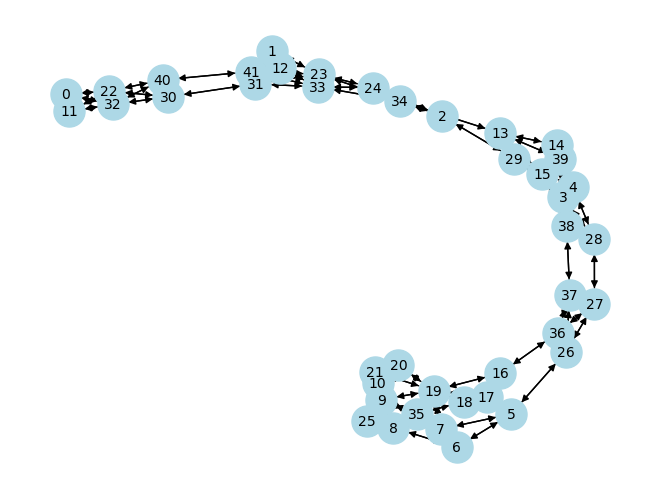

In [8]:
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_color='black')

## Training the Model

### Creating Training and Testing Data

We shuffle the dataset and split it into training and testing sets

In [9]:
torch.manual_seed(12345)

train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42)


print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

Number of training graphs: 890
Number of test graphs: 223


Let us create the dataloaders to effectively batch the graph inputs. Batching graphs is implemented extremely effectively in PyG and that has been used in this example.

In [10]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

for step, data in enumerate(train_loader):
    print(f'Step {step + 1}:')
    print('=======')
    print(f'Number of graphs in the current batch: {data.num_graphs}')
    print(data)
    print()

Step 1:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 8420], x=[2241, 3], y=[64], batch=[2241], ptr=[65])

Step 2:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 8162], x=[2177, 3], y=[64], batch=[2177], ptr=[65])

Step 3:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 9430], x=[2623, 3], y=[64], batch=[2623], ptr=[65])

Step 4:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 7562], x=[2122, 3], y=[64], batch=[2122], ptr=[65])

Step 5:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 10636], x=[2819, 3], y=[64], batch=[2819], ptr=[65])

Step 6:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 8392], x=[2276, 3], y=[64], batch=[2276], ptr=[65])

Step 7:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 8856], x=[2347, 3], y=[64], batch=[2347], ptr=[65])

Step 8:
Number of graphs in the current batch: 64
DataBatch(edge_index=[2, 7722], x=[2125, 3], y=[64], 

### Implementing the Model

To perform the classification, we use a very simple model with three graph convolution layers implemented in PyTorch Geometric.

In [13]:
from torch.nn import Linear
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool


class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        # self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        #optional MLP (maybe increased expressivity?)
        self.mlp = nn.Sequential(   
            Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            Linear(hidden_channels, dataset.num_classes)
        )

        # ok for this dataset
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        # x = self.conv2(x, edge_index)
        # x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        # x = self.mlp(x)

        return x

model = GCN(hidden_channels=64)
print(model)

GCN(
  (conv1): GCNConv(3, 64)
  (conv3): GCNConv(64, 64)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


In [15]:
#training loop
params = model.parameters()
optim = torch.optim.Adam(params, lr = 0.001)
criterion = nn.CrossEntropyLoss()
model.to(device)
model.train()
epochs = 10

for epoch in tqdm(range(epochs)):
    total_samples = 0
    total_correct = 0
    for data in train_loader:
        data.to(device)

        logits = model(data.x, data.edge_index, data.batch)
        actual_labels = data.y
        loss = criterion(logits, actual_labels)
        loss.backward()
        optim.step()
        optim.zero_grad()

        preds = torch.argmax(logits, dim = 1)
        total_correct += (preds == actual_labels).sum().item()
        total_samples += actual_labels.size(0)

    epoch_accuracy = total_correct / total_samples * 100

print(f"Epoch {epoch+1} Accuracy: {epoch_accuracy:.2f}%")


100%|██████████| 10/10 [00:01<00:00,  6.84it/s]

Epoch 10 Accuracy: 67.75%


In [ ]:
#test loop

model.eval()

num_correct = 0
num_samples = 0
test_loss = 0

with torch.no_grad():
    for test_data in test_loader:
        test_data.to(device)
        test_logits = model(test_data.x, test_data.edge_index, test_data.batch)
        loss = criterion(test_logits, test_data.y)
        test_loss += loss.item()
        test_preds = torch.argmax(test_logits, dim=1)
        num_correct += (test_preds == test_data.y).sum().item()
        num_samples += test_data.y.size(0)

test_accuracy = num_correct / num_samples * 100
test_loss /= len(test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
    

Test Accuracy: 66.82%
Test Loss: 0.6531


### Training

In the following cell, start a new W&B run and using the `use_artifact` function, we tell W&B that the given artifact is being used as input to this run.

**Note:** Usage of Weights & Biases for training is optional, in case you don't wish to use it, simply uncheck `use_wandb`.

In [ ]:

model = GCN(hidden_channels=64)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()

    for data in train_loader:  # Iterate in batches over the training dataset.
         out = model(data.x, data.edge_index, data.batch)  # Perform a single forward pass.
         loss = criterion(out, data.y)  # Compute the loss.
         loss.backward()  # Derive gradients.
         optimizer.step()  # Update parameters based on gradients.
         optimizer.zero_grad()  # Clear gradients.

In [ ]:
def test(loader, create_table=False):
     model.eval()
     table = wandb.Table(columns=['graph', 'ground truth', 'prediction']) if use_wandb else None
     correct = 0
     loss_ = 0
     for data in loader:  # Iterate in batches over the training/test dataset.
         out = model(data.x, data.edge_index, data.batch)
         loss = criterion(out, data.y)
         loss_ += loss.item()
         pred = out.argmax(dim=1)  # Use the class with highest probability.

         if create_table and use_wandb:
            table.add_data(wandb.Html(plotly.io.to_html(create_graph(data))), data.y.item(), pred.item())

         correct += int((pred == data.y).sum())  # Check against ground-truth labels.
     return correct / len(loader.dataset), loss_ / len(loader.dataset), table  # Derive ratio of correct predictions.

The great thing about PyG is that all the code is very similar to PyTorch and you can use the same training logic which is what has been done in the following cell. We calculate the accuracy and loss on the training and validation sets and long them to our W&B dashboard.

We also log the table that was mentioned above to the run dashboard for debugging.

In [ ]:
for epoch in trange(1, 171):
    train()
    train_acc, train_loss, _ = test(train_loader)
    test_acc, test_loss, test_table = test(test_loader, create_table=True)

    # Log metrics to W&B
    if use_wandb:
        wandb.log({
            "train/loss": train_loss,
            "train/acc": train_acc,
            "test/acc": test_acc,
            "test/loss": test_loss,
            "test/table": test_table
        })

    torch.save(model, "graph_classification_model.pt")

    # Log model checkpoint as an artifact to W&B
    if use_wandb:
        artifact = wandb.Artifact(name="graph_classification_model", type="model")
        artifact.add_file("graph_classification_model.pt")
        wandb.log_artifact(artifact)


# Finish the W&B run
if use_wandb:
    wandb.finish()

  0%|          | 0/170 [00:00<?, ?it/s]


NameError: name 'use_wandb' is not defined

This is what the project dashboard looks like and you can interact with it i.e. make the panels larger or smaller and more!

In [ ]:
test_acc, test_loss, test_table = test(test_loader, create_table=True)

In [ ]:
test_acc

0.7894736842105263